# ERCOT Price Distribution and Spike Threshold Definition

## 1. Setup and data load

Thi dataset is the result of joining three sources on the hourly `datetime` (CT) and `Location` keys:
- ERCOT Day-Ahead Market Settlement Point Prices (`SPP`, the price column),
- Open-Meteo hourly weather features by representative city per zone,
- FRED Henry Hub daily natural gas spot price (forward-filled to every hour).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'ercot_merged_dataset.parquet'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 12,
})

df = pd.read_parquet(DATA_PATH)
df['year'] = df['datetime'].dt.year

## 2. Summary statistics — all locations combined

I included the mean, median, standard deviation, plus two shape statistics:
- Skewness — a positive value means the right tail is heavier than the left. For ERCOT prices I expect strong positive skew because the floor is near zero (with some small negatives) while the ceiling is the administrative price cap.
- Excess kurtosis — measures tail-heaviness relative to a normal distribution

I report percentiles at greater granularity towards the upper end -- the gap between the 95th and 99.9th percentiles can inform our decision on where the spike threshold might be. 

In [2]:
PERCENTILES = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

def price_stats(series: pd.Series) -> pd.Series:
    s = series.dropna()
    out = {
        'n': len(s),
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(),
        'skew': stats.skew(s),
        'kurtosis': stats.kurtosis(s),
    }
    for p in PERCENTILES:
        out[f'p{p*100:g}'] = s.quantile(p)
    return pd.Series(out)

overall = price_stats(df['SPP'])
print('=== SPP summary — all locations, all years ===')
print(overall.round(2).to_string())

=== SPP summary — all locations, all years ===
n           763213.00
mean            55.08
median          24.21
std            352.07
skew            20.34
kurtosis       448.83
p1              -1.96
p5               9.10
p10             12.65
p25             17.43
p50             24.21
p75             37.74
p90             62.11
p95             91.63
p99            342.60
p99.5          920.09
p99.9         7699.53


**Takeaways**  
The mean sits well above the median. The large positive skewness and very high excess kurtosis confirm this is nowhere near Gaussian; treating SPP as normally distributed (e.g., fitting OLS directly on the raw price) would systematically understate the probability of extreme events. The jump from the 99th to the 99.9th percentile is quite telling too: it represents an insane 22x increase in the price too.

## 3. Summary statistics per hub / load zone

ERCOT publishes prices at two kinds of settlement points in this dataset:
- **Load Zones** (`LZ_*`) — aggregated settlement points where load (demand) pays.
- **Hubs** (`HB_*`) — trading hubs that aren’t tied to a specific load; they are the liquid reference points for financial contracts.

The distributions should differ: load zones in congested parts of the grid can spike independently of hubs. I want to see whether a single grid-wide spike threshold makes sense, or whether I should use per-location thresholds.

In [3]:
per_loc = df.groupby('Location')['SPP'].apply(price_stats).unstack()
per_loc = per_loc.reindex(sorted(per_loc.index))
print('=== SPP summary by Location ===')
print(per_loc.round(2).to_string())

=== SPP summary by Location ===
                  n   mean  median     std   skew  kurtosis     p1     p5    p10    p25    p50    p75    p90    p95     p99   p99.5    p99.9
Location                                                                                                                                    
HB_BUSAVG   63791.0  54.58   23.88  351.11  20.41    451.69   4.52  10.32  13.00  17.30  23.88  36.86  60.66  89.26  333.98  900.41  7676.46
HB_HOUSTON  63791.0  56.34   25.04  351.03  20.40    451.42   6.21  11.53  13.98  18.18  25.04  38.94  63.60  93.64  339.98  903.63  7676.79
HB_HUBAVG   63791.0  54.58   23.99  350.99  20.42    451.84   4.14   9.96  12.72  17.22  23.99  37.00  60.90  89.66  335.23  900.48  7676.42
HB_NORTH    63791.0  54.61   23.66  351.68  20.38    450.43   4.50  10.26  12.94  17.19  23.66  36.84  60.48  89.24  341.06  914.15  7679.42
HB_PAN      61512.0  48.15   19.26  358.91  19.93    431.82 -22.67 -12.82  -4.42   8.47  19.26  33.01  58.00  87.26  355.2

**Takeaways** 
Medians are tightly clustered across locations (everything is downstream of the same natural-gas-driven marginal cost), but tail behavior diverges sharply. Locations with higher p99.9 are the ones most exposed to scarcity-priced hours. The hubs are generally a little less extreme than their co-located load zones. This might be because hubs average across a wider footprint. 

## 4. Summary statistics per year

I want to check whether the distribution is the same from year to year. If it isn’t then a spike threshold calibrated on pooled data might mis-represent any single year, and I then need to consider train/test splits that respect the time ordering. 2021 in particular contains Winter Storm Uri (Feb 2021), which pegged ERCOT at its \$9,000/MWh price cap for days.

In [4]:
per_year = df.groupby('year')['SPP'].apply(price_stats).unstack()
print('=== SPP summary by year ===')
print(per_year.round(2).to_string())

=== SPP summary by year ===
             n    mean  median     std   skew  kurtosis     p1     p5    p10    p25    p50    p75     p90     p95      p99    p99.5    p99.9
year                                                                                                                                        
2019  102841.0   38.28   21.03  166.02  17.89    381.46   2.01  11.77  13.87  16.99  21.03  27.80   40.61   56.59   301.72   799.27  2708.42
2020  105408.0   22.02   17.81   37.50  29.91   1292.31 -11.99   8.40  11.01  13.95  17.81  23.98   33.23   42.97    88.79   133.25   531.29
2021  105120.0  146.02   28.20  892.28   8.46     71.94  -8.25  11.19  16.03  20.56  28.20  40.55   61.34   87.97  7017.92  8057.42  8988.13
2022  105120.0   65.22   48.42   90.94  12.23    238.25   1.42  17.60  23.69  34.20  48.42  69.73  106.69  146.37   399.14   565.27  1294.36
2023  105120.0   56.14   22.34  218.07  11.59    157.17   0.57  10.46  13.30  17.37  22.34  32.27   64.43  132.36   787.72  17

The mean is far more volatile year-to-year than the median. The p99 and p99.9 columns are where the regime shift shows up most clearly: Uri pushes 2021’s upper tail to the \$9,000 administrative price cap, and the post-Uri years settle somewhere between the calm pre-Uri baseline and that peak. Practically, this means a single pooled percentile threshold will over-flag hours in calm years and under-flag them in volatile ones. I need to remember this when evlauating performance.

## 5. Histogram of SPP with log-scaled y-axis

Switching the y-axis to log lets the low-frequency spike bins show up. I overlay dashed vertical lines at the 90th, 95th, and 99th percentiles. 

I clipped the x-axis to a readable window (negatives → \$1,500). 

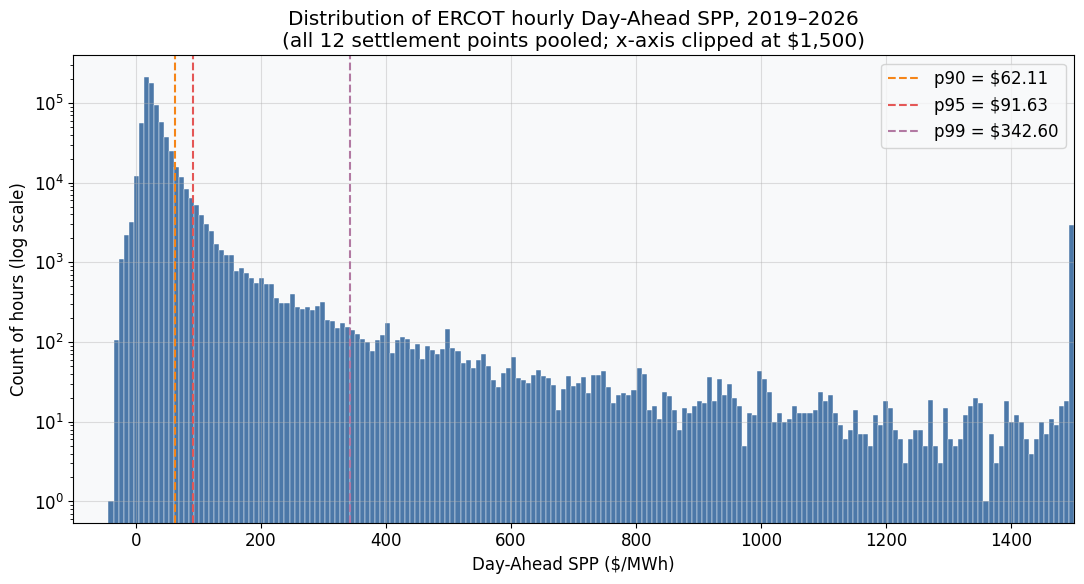

Saved -> outputs/price_distribution.png


In [5]:
spp = df['SPP'].dropna()
p90, p95, p99 = spp.quantile([0.90, 0.95, 0.99]).tolist()

x_min, x_max = -100, 1500
bins = np.linspace(x_min, x_max, 200)
clipped = spp.clip(lower=x_min, upper=x_max)

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(clipped, bins=bins, color='#4c78a8', edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Day-Ahead SPP ($/MWh)')
ax.set_ylabel('Count of hours (log scale)')
ax.set_title('Distribution of ERCOT hourly Day-Ahead SPP, 2019–2026\n(all 12 settlement points pooled; x-axis clipped at $1,500)')

for pct, val, color in [(90, p90, '#f58518'), (95, p95, '#e45756'), (99, p99, '#b279a2')]:
    ax.axvline(val, color=color, linestyle='--', linewidth=1.5,
               label=f'p{pct} = ${val:,.2f}')
ax.legend(loc='upper right')

out_path = OUTPUTS_DIR / 'price_distribution.png'
fig.tight_layout()
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path.relative_to(PROJECT_ROOT)}')

We can see that the split between P55/P99 forms a nice threshold for us to later further categorize spikes. 

## 6. Candidate spike thresholds

With the distribution characterized, I can evaluate concrete spike definitions. Two families are worth comparing:

1. **Percentile-based** Guarantees a fixed share of hours are labeled spikes, which is convenient for class balance, but drifts with the data: if 2027 is calm, an absolute level that was rare in 2021 might be merely elevated.
2. **Fixed-dollar** (absolute) — “any hour above \$100/MWh” or “above \$200/MWh.” Stable across re-runs of the pipeline, but can produce very unbalanced classes in calm periods.

In [6]:
p95_all = spp.quantile(0.95)
p99_all = spp.quantile(0.99)

candidates = {
    'p95 (relative)': p95_all,
    'p99 (relative)': p99_all,
    '$100/MWh (fixed)': 100.0,
    '$200/MWh (fixed)': 200.0,
    '$500/MWh (fixed)': 500.0,
}

print('=== Threshold values ===')
for name, thr in candidates.items():
    share = (spp > thr).mean()
    print(f'  {name:20s} threshold = ${thr:>8,.2f}   share of hours above = {share*100:6.2f}%')

print('\n=== Spike hours per year (per-location hours; divide by 12 for calendar-hour equivalent) ===')
counts_by_year = pd.DataFrame(
    {name: df.groupby('year')['SPP'].apply(lambda s, t=thr: (s > t).sum())
     for name, thr in candidates.items()}
)
print(counts_by_year.to_string())

=== Threshold values ===
  p95 (relative)       threshold = $   91.63   share of hours above =   5.00%
  p99 (relative)       threshold = $  342.60   share of hours above =   1.00%
  $100/MWh (fixed)     threshold = $  100.00   share of hours above =   4.27%
  $200/MWh (fixed)     threshold = $  200.00   share of hours above =   1.71%
  $500/MWh (fixed)     threshold = $  500.00   share of hours above =   0.74%

=== Spike hours per year (per-location hours; divide by 12 for calendar-hour equivalent) ===
      p95 (relative)  p99 (relative)  $100/MWh (fixed)  $200/MWh (fixed)  $500/MWh (fixed)
year                                                                                      
2019            3059             980              2735              1432               720
2020             969             133               841               330               107
2021            4956            2204              4368              2593              2021
2022           14962            1298

**Picking a working definition.** For the first round of modeling the \$100/MWh fixed threshold works: it sits in the same neighborhood as p95 on the pooled distribution. I will use that as the binary spike label for now, and carry the percentile thresholds along for severity tiers below.

## 7. Severity tiers

A binary spike / non-spike label loses information. We propose three percentile-based tiers above the 95th-percentile base threshold:

- **Moderate spike** — between p95 and p99. Unusual but within the range of a tight-but-functioning market.
- **Severe spike** — between p99 and p99.9. Scarcity conditions, reserves tight.
- **Extreme spike** — above p99.9. Real scarcity or emergency events, including the ERCOT price cap.

This gives us flexibility for analysis later. 

In [7]:
p95_v, p99_v, p999_v = spp.quantile([0.95, 0.99, 0.999]).tolist()

bins_edges = [-np.inf, p95_v, p99_v, p999_v, np.inf]
tier_labels = ['normal (<=p95)', 'moderate (p95-p99)', 'severe (p99-p99.9)', 'extreme (>p99.9)']
df['spike_tier'] = pd.cut(df['SPP'], bins=bins_edges, labels=tier_labels, include_lowest=True)

tier_summary = (
    df.groupby('spike_tier', observed=True)['SPP']
      .agg(count='size', mean_price='mean', median_price='median', min_price='min', max_price='max')
      .round(2)
)
tier_summary['share_%'] = (tier_summary['count'] / tier_summary['count'].sum() * 100).round(3)

print(f'Tier boundaries: p95=${p95_v:,.2f}  p99=${p99_v:,.2f}  p99.9=${p999_v:,.2f}')
print('\n=== Severity tier summary ===')
print(tier_summary.to_string())

Tier boundaries: p95=$91.63  p99=$342.60  p99.9=$7,699.53

=== Severity tier summary ===
                     count  mean_price  median_price  min_price  max_price  share_%
spike_tier                                                                         
normal (<=p95)      725059       27.75         23.39     -38.53      91.63   95.001
moderate (p95-p99)   30521      147.41        123.64      91.64     342.58    3.999
severe (p99-p99.9)    6869     1592.93        770.75     342.60    7697.80    0.900
extreme (>p99.9)       764     8480.62       8504.66    7700.00    9052.53    0.100


Here I can see that combining all the spike tiers into just one tier would be oversimplifying reality. 

---

## Takeaways

1. SPP is heavily right-skewed and fat-tailed; Gaussian assumptions on raw price are a non-starter. For regression I should use either a log transform, a gamma/tweedie loss, or an alternative method to take this into account.
2. The per-year breakdown shows the distribution is non-stationary (Uri is a once-in-decades event inside the training window). Any evaluation protocol must respect time ordering and report metrics both pooled and per-year.
3. For the first modeling pass I will use a **binary spike label at \$100/MWh** and use the 3 tier severity classification. 
4. Per-location thresholds may be needed later